In [1]:
!pip install pmdarima


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


### Load Dataset

In [3]:
import pandas as pd

df = pd.read_csv('data/saham_nvidia_stock.csv')
df.head()

,Date,Close,High,Low,Open,Volume
0,2015-01-02,0.482985,0.486584,0.475307,0.482985,113680000
1,2015-01-05,0.474827,0.484425,0.472668,0.482985,197952000
2,2015-01-06,0.460432,0.476027,0.459952,0.475547,197764000
3,2015-01-07,0.459232,0.467870,0.457792,0.463791,321808000
4,2015-01-08,0.476507,0.479386,0.464270,0.464510,283780000


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2864 entries, 0 to 2863
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    2864 non-null   object 
 1   Close   2864 non-null   float64
 2   High    2864 non-null   float64
 3   Low     2864 non-null   float64
 4   Open    2864 non-null   float64
 5   Volume  2864 non-null   int64  
dtypes: float64(4), int64(1), object(1)
memory usage: 134.4+ KB


In [5]:
df.isnull().sum()

Date      0
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64

### Import Library

In [6]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error

from statsmodels.tsa.arima.model import ARIMA
from pmdarima import auto_arima

### Preparation

In [7]:
# Jika Date masih kolom biasa
if 'Date' in df.columns:
    df['Date'] = pd.to_datetime(df['Date'])
    df = df.sort_values('Date')
    df = df.set_index('Date')

# index berbentuk datetime
df.index = pd.to_datetime(df.index)

# urutkan berdasarkan index
df = df.sort_index()

# set frequency business day untuk data saham
df = df.asfreq('B')

# isi missing value karena weekend dan hari libur
df['Close'] = df['Close'].ffill()

series = df['Close']

print(series.head())
print(series.index.freq)

Date
2015-01-02    0.482985
2015-01-05    0.474827
2015-01-06    0.460432
2015-01-07    0.459232
2015-01-08    0.476507
Freq: B, Name: Close, dtype: float64
<BusinessDay>


### Train Test Split

In [8]:
# 80% Train
train_size = int(len(series) * 0.8)

train = series[:train_size]
test = series[train_size:]

print("Training 80%:", len(train))
print("Test 20%:", len(test))

Training 80%: 2376
Test 20%: 595


### Define Best Parameter

In [9]:
# Mencari parameter terbaik (p,d,q)

auto_model = auto_arima(
    train,
    seasonal=False,
    stepwise=True,
    suppress_warnings=True,
    trace=True
)

print(auto_model.summary())

Performing stepwise search to minimize aic
 ARIMA(2,2,2)(0,0,0)[0] intercept   : AIC=3478.513, Time=3.29 sec
 ARIMA(0,2,0)(0,0,0)[0] intercept   : AIC=5108.405, Time=0.39 sec
 ARIMA(1,2,0)(0,0,0)[0] intercept   : AIC=4463.670, Time=0.36 sec
 ARIMA(0,2,1)(0,0,0)[0] intercept   : AIC=3488.475, Time=1.43 sec
 ARIMA(0,2,0)(0,0,0)[0]             : AIC=5106.410, Time=0.28 sec
 ARIMA(1,2,2)(0,0,0)[0] intercept   : AIC=3481.129, Time=2.83 sec
 ARIMA(2,2,1)(0,0,0)[0] intercept   : AIC=3490.634, Time=2.66 sec
 ARIMA(3,2,2)(0,0,0)[0] intercept   : AIC=3479.336, Time=4.39 sec
 ARIMA(2,2,3)(0,0,0)[0] intercept   : AIC=3478.194, Time=5.42 sec
 ARIMA(1,2,3)(0,0,0)[0] intercept   : AIC=3478.333, Time=4.04 sec
 ARIMA(3,2,3)(0,0,0)[0] intercept   : AIC=3479.687, Time=6.28 sec
 ARIMA(2,2,4)(0,0,0)[0] intercept   : AIC=3479.682, Time=6.77 sec
 ARIMA(1,2,4)(0,0,0)[0] intercept   : AIC=3480.744, Time=4.69 sec
 ARIMA(3,2,4)(0,0,0)[0] intercept   : AIC=inf, Time=6.61 sec
 ARIMA(2,2,3)(0,0,0)[0]             : 

In [10]:
# model terbaik
order = auto_model.order
print("Best ARIMA order:", order)

model = ARIMA(train, order=order)
model_fit = model.fit()

print(model_fit.summary())

Best ARIMA order: (2, 2, 3)
                               SARIMAX Results                                
Dep. Variable:                  Close   No. Observations:                 2376
Model:                 ARIMA(2, 2, 3)   Log Likelihood               -1729.734
Date:                Mon, 08 Jun 2026   AIC                           3471.467
Time:                        13:51:27   BIC                           3506.101
Sample:                    01-02-2015   HQIC                          3484.074
                         - 02-09-2024                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -1.7289      0.049    -34.929      0.000      -1.826      -1.632
ar.L2         -0.8251      0.043    -18.983      0.000      -0.910      -0.740
ma.L1          0.7478   

### Prediksi

In [11]:
predictions = model_fit.forecast(steps=len(test))

predictions.index = test.index

print(predictions.head())

Date
2024-02-12    72.616836
2024-02-13    72.625804
2024-02-14    73.248975
2024-02-15    73.238391
2024-02-16    73.816749
Freq: B, Name: predicted_mean, dtype: float64


### Evaluasi

In [12]:
rmse = np.sqrt(mean_squared_error(test, predictions))

mape = mean_absolute_percentage_error(test, predictions) * 100

mean_price = series.mean()
rmse_percent = (rmse / mean_price) * 100

print("Mean :", mean_price)
print(f"RMSE: {rmse:.2f}")
# print(f"RMSE (%): {rmse_percent:.2f}%")
print(f"MAPE: {mape:.2f}%")

Mean : 38.308910868377325
RMSE: 30.01
MAPE: 16.37%


### Training Ulang

In [13]:
final_model_fit = ARIMA(series, order=order).fit()

c:\Users\LENOVO\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


### Prediksi 30 hari kedepan

In [14]:
forecast_30 = final_model_fit.forecast(steps=30)

print(forecast_30)

2026-05-25    215.435207
2026-05-26    215.817893
2026-05-27    215.850861
2026-05-28    216.019536
2026-05-29    216.364351
2026-06-01    216.380421
2026-06-02    216.604127
2026-06-03    216.902287
2026-06-04    216.919434
2026-06-05    217.186017
2026-06-08    217.434361
2026-06-09    217.467672
2026-06-10    217.762949
2026-06-11    217.963356
2026-06-12    218.024098
2026-06-15    218.333472
2026-06-16    218.491906
2026-06-17    218.587092
2026-06-18    218.896942
2026-06-19    219.022274
2026-06-22    219.154683
2026-06-23    219.453461
2026-06-24    219.556208
2026-06-25    219.724786
2026-06-26    220.003751
2026-06-29    220.094856
2026-06-30    220.295413
2026-07-01    220.548987
2026-07-02    220.638759
2026-07-03    220.864836
Freq: B, Name: predicted_mean, dtype: float64


### Tanggal Prediksi

In [15]:
future_dates = pd.date_range(
    start=series.index[-1] + pd.Timedelta(days=1),
    periods=30,
    freq='D'
)

forecast_df = pd.DataFrame({
    'Date': future_dates,
    'Forecast': forecast_30.values
})

forecast_df

,Date,Forecast
0,2026-05-23,215.435207
1,2026-05-24,215.817893
2,2026-05-25,215.850861
3,2026-05-26,216.019536
4,2026-05-27,216.364351
5,2026-05-28,216.380421
6,2026-05-29,216.604127
7,2026-05-30,216.902287
8,2026-05-31,216.919434
9,2026-06-01,217.186017


### Visualisasi

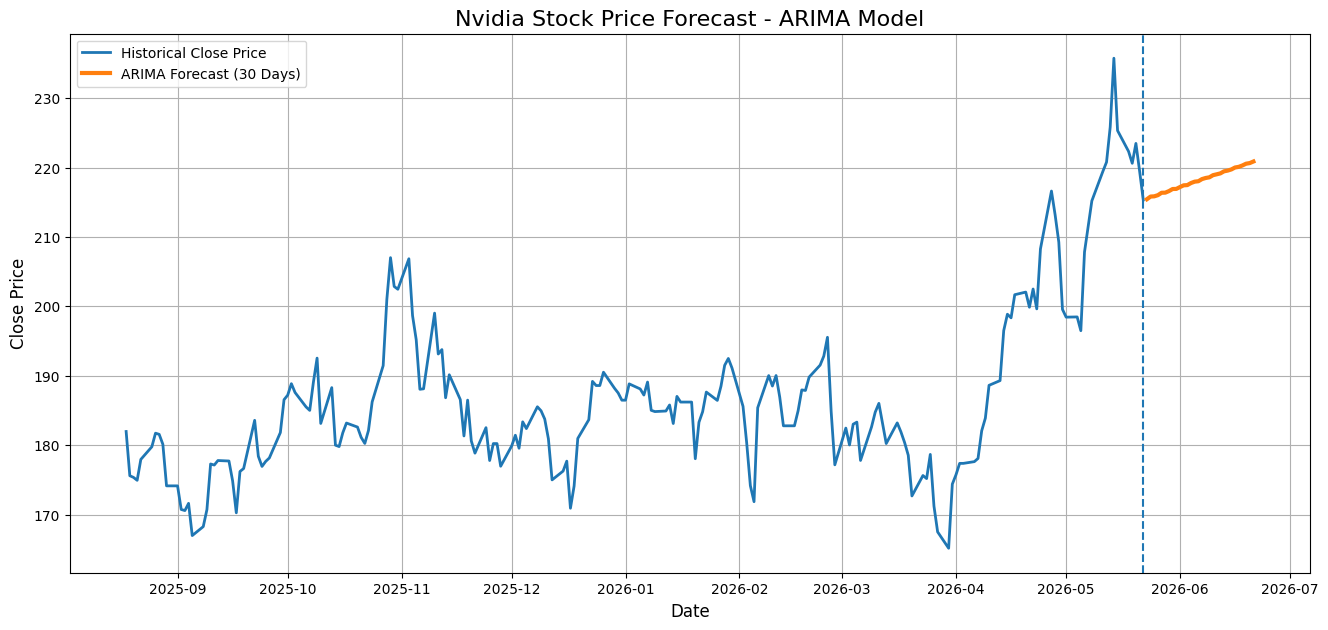

In [17]:
plt.figure(figsize=(16,7))

# data historis 200 hari terakhir
plt.plot(
    series.index[-200:],
    series[-200:],
    label='Historical Close Price',
    linewidth=2
)

# forecast 30 hari
plt.plot(
    forecast_df['Date'],
    forecast_df['Forecast'],
    label='ARIMA Forecast (30 Days)',
    linewidth=3
)

# titik awal forecast
plt.axvline(
    x=series.index[-1],
    linestyle='--'
)

plt.title('Nvidia Stock Price Forecast - ARIMA Model', fontsize=16)

plt.xlabel('Date', fontsize=12)
plt.ylabel('Close Price', fontsize=12)

plt.legend()

plt.grid(True)

plt.show()

### Visualisasi Model Arima

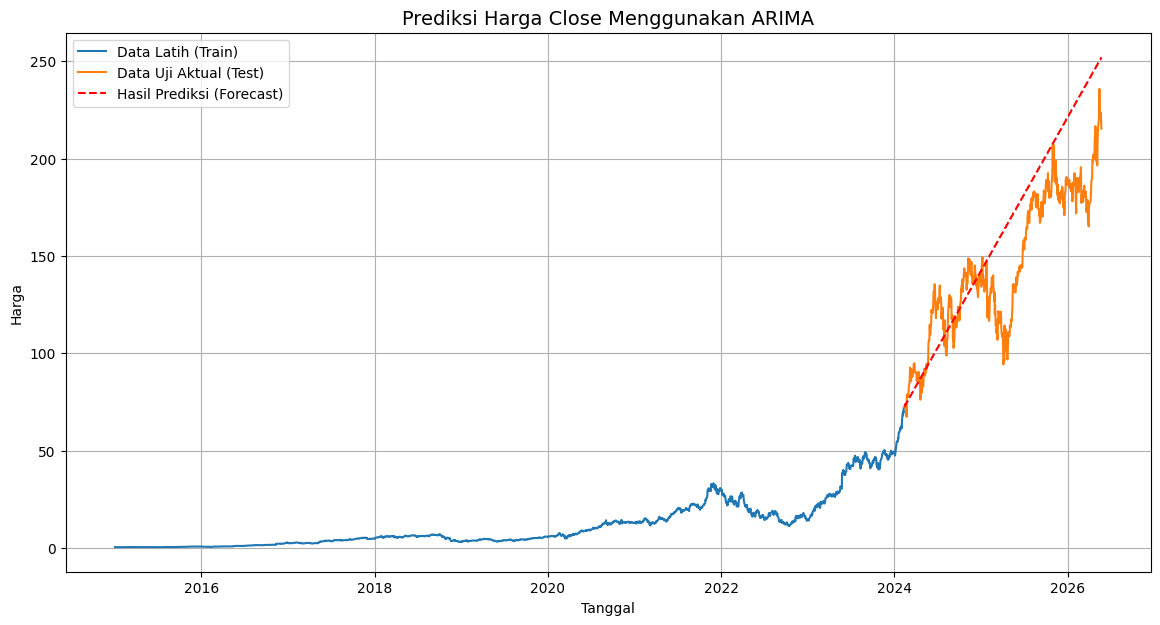

In [18]:
# Visualisasi prediksi harga close with arima
plt.figure(figsize=(14,7))
plt.plot(train, label='Data Latih (Train)')
plt.plot(test, label='Data Uji Aktual (Test)')
plt.plot(predictions, label='Hasil Prediksi (Forecast)', color='red', linestyle='--')
plt.title('Prediksi Harga Close Menggunakan ARIMA', fontsize=14)
plt.xlabel('Tanggal')
plt.ylabel('Harga')
plt.legend()
plt.grid(True)
plt.show()